In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import files
import io
#Load Titanic dataset
uploaded = files.upload()
titanic = pd.read_csv("titanic.csv")
#check
print(titanic.head())

Saving titanic.csv to titanic (2).csv
   pclass  survived                                             name     sex  \
0       1         1                    Allen, Miss. Elisabeth Walton  female   
1       1         1                   Allison, Master. Hudson Trevor    male   
2       1         0                     Allison, Miss. Helen Loraine  female   
3       1         0             Allison, Mr. Hudson Joshua Creighton    male   
4       1         0  Allison, Mrs. Hudson J C (Bessie Waldo Daniels)  female   

       age  sibsp  parch  ticket      fare    cabin embarked boat   body  \
0  29.0000      0      0   24160  211.3375       B5        S    2    NaN   
1   0.9167      1      2  113781  151.5500  C22 C26        S   11    NaN   
2   2.0000      1      2  113781  151.5500  C22 C26        S  NaN    NaN   
3  30.0000      1      2  113781  151.5500  C22 C26        S  NaN  135.0   
4  25.0000      1      2  113781  151.5500  C22 C26        S  NaN    NaN   

                        

In [6]:
# Clean data
if 'Age' in titanic.columns:
    titanic['Age'] = titanic['Age'].fillna(titanic['Age'].median())
else:
    titanic['age'] = titanic['age'].fillna(titanic['age'].median())

# Check if missing values are resolved
print(titanic.isnull().sum())

pclass          0
survived        0
name            0
sex             0
age             0
sibsp           0
parch           0
ticket          0
fare            1
cabin        1014
embarked        2
boat          823
body         1188
home.dest     564
dtype: int64


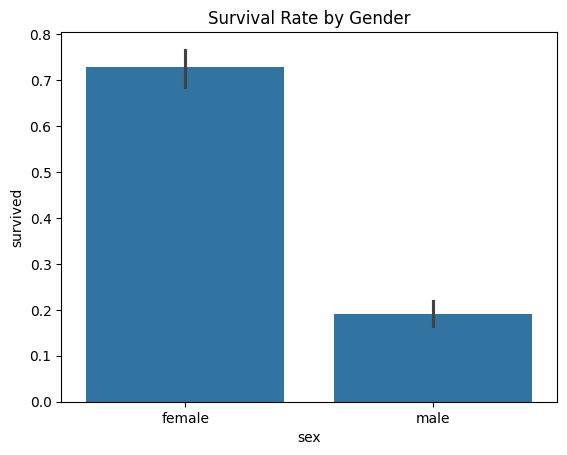

In [7]:
# Determine survival rate by gender
col_sex = 'Sex' if 'Sex' in titanic.columns else 'sex'
col_survived = 'Survived' if 'Survived' in titanic.columns else 'survived'

sns.barplot(x=col_sex, y=col_survived, data=titanic)
plt.title("Survival Rate by Gender")
plt.show()

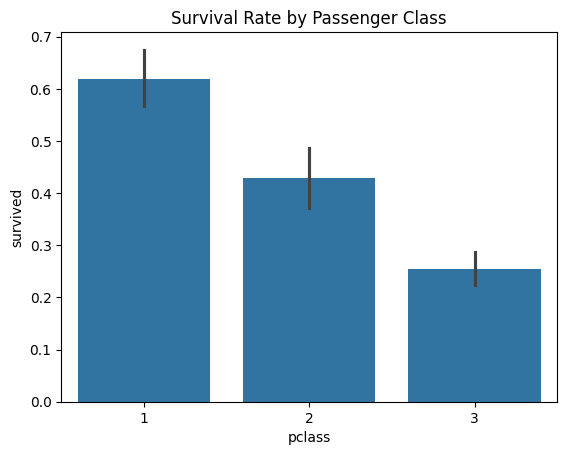

In [8]:
# Determine survival rate by passenger class
col_pclass = 'Pclass' if 'Pclass' in titanic.columns else 'pclass'

sns.barplot(x=col_pclass, y=col_survived, data=titanic)
plt.title("Survival Rate by Passenger Class")
plt.show()

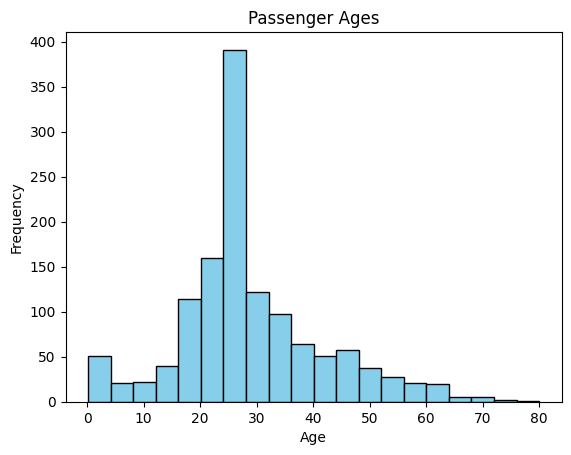

In [9]:
# Histogram of passenger ages
col_age = 'Age' if 'Age' in titanic.columns else 'age'

titanic[col_age].plot(kind="hist", bins=20, title="Passenger Ages", color='skyblue', edgecolor='black')
plt.xlabel("Age")
plt.show()

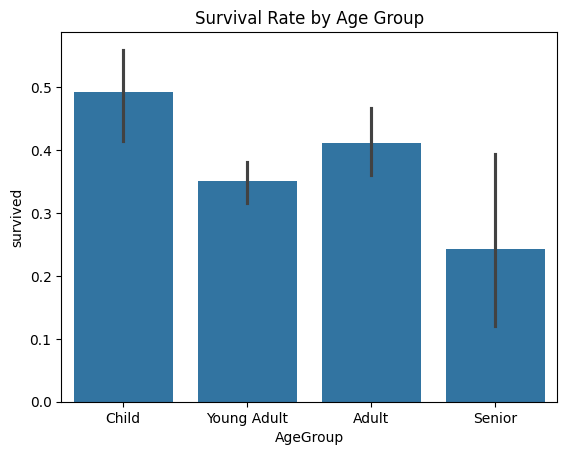

In [10]:
# Define age groups and calculate survival rates
age_bins = [0, 18, 35, 60, 100]
age_labels = ['Child', 'Young Adult', 'Adult', 'Senior']
titanic['AgeGroup'] = pd.cut(titanic[col_age], bins=age_bins, labels=age_labels)

sns.barplot(x='AgeGroup', y=col_survived, data=titanic)
plt.title("Survival Rate by Age Group")
plt.show()